In [1]:
# BLOCK 1: Preprocess raw Yelp images (128x128), skip unreadables, and save

import os
from PIL import Image, UnidentifiedImageError
from tqdm import tqdm
import torchvision.transforms as transforms

input_folder = './photos'            # All raw Yelp images (flat folder)
output_folder = './yelp_images_cleaned_64/dummy' # Need subfolder for ImageFolder

os.makedirs(output_folder, exist_ok=True)

preprocess = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
])

for filename in tqdm(os.listdir(input_folder), desc="Preprocessing Images"):
    src_path = os.path.join(input_folder, filename)
    dst_path = os.path.join(output_folder, filename)
    
    try:
        with Image.open(src_path) as img:
            img = img.convert('RGB')  # Ensure 3 channels
            img = preprocess(img)
            img.save(dst_path)
    except (UnidentifiedImageError, OSError) as e:
        print(f"Skipped: {filename} — {e}")


In [2]:
# BLOCK 2 (Modified): Limit dataset to 10,000 images

from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader, Subset

batch_size = 64

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

# Load full dataset
full_dataset = ImageFolder(root='./yelp_images_cleaned_64', transform=transform)

# Limit to first 10,000 samples
subset_indices = list(range(min(10000, len(full_dataset))))
dataset = Subset(full_dataset, subset_indices)

# DataLoader
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=4)

print(f"Using {len(dataset)} images for training.")


Using 10000 images for training.


In [3]:
# BLOCK 3: DCGAN Generator & Discriminator

import torch
import torch.nn as nn

nz = 100
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")


class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz, 1024, 4, 1, 0, bias=False),
            nn.BatchNorm2d(1024),
            nn.ReLU(True),

            nn.ConvTranspose2d(1024, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        return self.main(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(3, 128, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 1024, 4, 2, 1, bias=False),
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(1024, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, img):
        return self.main(img).view(-1)


In [4]:
# BLOCK 4: Train the DCGAN (with tqdm, timing, and image saving)

import torch.optim as optim
from torchvision.utils import save_image, make_grid
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import time
import os

# Create output directory
os.makedirs("dcgan_outputs", exist_ok=True)

# Initialize models
G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()
optimizerD = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerG = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))

real_label = 1.
fake_label = 0.
num_epochs = 100
nz = 100  # latent vector size (set to your actual value)

# Fixed noise for image comparison
# fixed_noise = torch.randn(64, nz, 1, 1, device=device)
fixed_noise = torch.randn(10, nz, 1, 1, device=device)


start_time = time.time()

for epoch in range(num_epochs):

    if (epoch + 1) % 5 == 0 or (epoch + 1) <= 3:
        loop = tqdm(dataloader, leave=True)
    else:
        loop = dataloader
    # loop = tqdm(dataloader, leave=True)
    loop.set_description(f"Epoch [{epoch+1}/{num_epochs}]")

    for i, (real_imgs, _) in enumerate(loop):
        real_imgs = real_imgs.to(device)
        b_size = real_imgs.size(0)

        # === Train Discriminator ===
        D.zero_grad()
        output_real = D(real_imgs)
        labels_real = torch.full(output_real.shape, real_label, device=device)
        lossD_real = criterion(output_real, labels_real)
        lossD_real.backward()

        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake_imgs = G(noise)
        output_fake = D(fake_imgs.detach())
        labels_fake = torch.full(output_fake.shape, fake_label, device=device)
        lossD_fake = criterion(output_fake, labels_fake)
        lossD_fake.backward()
        optimizerD.step()

        # === Train Generator ===
        G.zero_grad()
        output_gen = D(fake_imgs)
        labels_gen = torch.full(output_gen.shape, real_label, device=device)
        lossG = criterion(output_gen, labels_gen)
        lossG.backward()
        optimizerG.step()

        # Update tqdm progress bar
        loop.set_postfix({
            "Loss D": f"{(lossD_real + lossD_fake).item():.4f}",
            "Loss G": f"{lossG.item():.4f}"
        })

    # Save generated images every 5 epochs
    if (epoch + 1) % 5 == 0:
        with torch.no_grad():
            fake_images = G(fixed_noise).detach().cpu()
            save_image(
                fake_images, 
                f"dcgan_outputs/epoch_{epoch+1:03d}.png",
                nrow=5,             # 5 images per row (2 rows for 10 images)
                normalize=True
            )
        # Save generated images for first 3 epochs
    elif (epoch + 1) <= 3:
        with torch.no_grad():
            fake_images = G(fixed_noise).detach().cpu()
            save_image(
                fake_images, 
                f"dcgan_outputs/epoch_{epoch+1:03d}.png",
                nrow=5,             # 5 images per row (2 rows for 10 images)
                normalize=True
            )

# Report total training time
end_time = time.time()
minutes, seconds = divmod(end_time - start_time, 60)
print(f"\nTraining complete in {int(minutes)} min {int(seconds)} sec")


Epoch [100/100]: 100%|██████████| 157/157 [01:06<00:00,  2.36it/s, Loss D=0.3846, Loss G=6.9183] 


Training complete in 110 min 52 sec


In [9]:
torch.save(G.state_dict(), "generator_100.pth")
torch.save(D.state_dict(), "discriminator_100.pth")


In [10]:
G = Generator().to(device)
D = Discriminator().to(device)

G.load_state_dict(torch.load("generator_100.pth"))
D.load_state_dict(torch.load("discriminator_100.pth"))

# Make sure you're still using the same optimizers
optimizerD = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerG = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))


In [11]:
torch.save({
    'G_state_dict': G.state_dict(),
    'D_state_dict': D.state_dict(),
    'optimizerG_state_dict': optimizerG.state_dict(),
    'optimizerD_state_dict': optimizerD.state_dict(),
}, 'dcgan_checkpoint_100.pth')


In [12]:
checkpoint = torch.load('dcgan_checkpoint_100.pth')
G.load_state_dict(checkpoint['G_state_dict'])
D.load_state_dict(checkpoint['D_state_dict'])
optimizerG.load_state_dict(checkpoint['optimizerG_state_dict'])
optimizerD.load_state_dict(checkpoint['optimizerD_state_dict'])


In [16]:
start_epoch = 101
num_epochs = 200

start_time = time.time()

for epoch in range(start_epoch, num_epochs + 1):
    epoch_start_time = time.time()
    
    # Always use tqdm for progress bar
    loop = tqdm(dataloader, leave=True)
    loop.set_description(f"Epoch [{epoch}/{num_epochs}]")

    running_loss_D = 0.0
    running_loss_G = 0.0

    for i, (real_imgs, _) in enumerate(loop):
        real_imgs = real_imgs.to(device)
        b_size = real_imgs.size(0)

        # === Train Discriminator ===
        D.zero_grad()
        output_real = D(real_imgs)
        labels_real = torch.full(output_real.shape, real_label, device=device)
        lossD_real = criterion(output_real, labels_real)
        lossD_real.backward()

        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake_imgs = G(noise)
        output_fake = D(fake_imgs.detach())
        labels_fake = torch.full(output_fake.shape, fake_label, device=device)
        lossD_fake = criterion(output_fake, labels_fake)
        lossD_fake.backward()
        optimizerD.step()

        # === Train Generator ===
        G.zero_grad()
        output_gen = D(fake_imgs)
        labels_gen = torch.full(output_gen.shape, real_label, device=device)
        lossG = criterion(output_gen, labels_gen)
        lossG.backward()
        optimizerG.step()

        # Accumulate losses for reporting
        running_loss_D += (lossD_real + lossD_fake).item()
        running_loss_G += lossG.item()

        # Update tqdm progress bar
        loop.set_postfix({
            "Loss D": f"{(lossD_real + lossD_fake).item():.4f}",
            "Loss G": f"{lossG.item():.4f}"
        })

    # === Save generated images every 5 epochs OR for first 3
    if (epoch % 5 == 0) or (epoch <= 103):
        with torch.no_grad():
            fake_images = G(fixed_noise).detach().cpu()
            save_image(
                fake_images, 
                f"dcgan_outputs/epoch_{epoch:03d}.png",
                nrow=5,
                normalize=True
            )

    # === Print epoch summary every 5 epochs
    if epoch % 5 == 0:
        epoch_time = time.time() - epoch_start_time
        print(f"\n[Epoch {epoch}] Loss_D: {running_loss_D / len(dataloader):.4f} | "
              f"Loss_G: {running_loss_G / len(dataloader):.4f} | "
              f"Time: {epoch_time:.2f} sec")

# Report total training time
end_time = time.time()
minutes, seconds = divmod(end_time - start_time, 60)
print(f"\nTraining complete in {int(minutes)} min {int(seconds)} sec")


Epoch [175/200]: 100%|██████████| 157/157 [01:06<00:00,  2.36it/s, Loss D=0.0033, Loss G=9.4901] 



[Epoch 175] Loss_D: 0.0571 | Loss_G: 6.9787 | Time: 66.49 sec


Epoch [180/200]: 100%|██████████| 157/157 [01:06<00:00,  2.36it/s, Loss D=1.0600, Loss G=16.3637] 



[Epoch 180] Loss_D: 0.8374 | Loss_G: 7.5912 | Time: 66.55 sec


Epoch [185/200]: 100%|██████████| 157/157 [01:06<00:00,  2.36it/s, Loss D=0.0837, Loss G=6.8752] 


...


[Epoch 190] Loss_D: 0.1190 | Loss_G: 7.6412 | Time: 66.74 sec


Epoch [195/200]: 100%|██████████| 157/157 [01:06<00:00,  2.36it/s, Loss D=0.1662, Loss G=10.0734]



[Epoch 195] Loss_D: 0.0875 | Loss_G: 6.4570 | Time: 66.73 sec


Epoch [200/200]: 100%|██████████| 157/157 [01:06<00:00,  2.36it/s, Loss D=0.1319, Loss G=5.8445]


[Epoch 200] Loss_D: 0.0545 | Loss_G: 6.6815 | Time: 66.59 sec

Training complete in 111 min 7 sec


In [17]:
torch.save(G.state_dict(), "generator_200.pth")
torch.save(D.state_dict(), "discriminator_200.pth")


In [18]:
G = Generator().to(device)
D = Discriminator().to(device)

G.load_state_dict(torch.load("generator_200.pth"))
D.load_state_dict(torch.load("discriminator_200.pth"))

# Make sure you're still using the same optimizers
optimizerD = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerG = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))

In [19]:
torch.save({
    'G_state_dict_1': G.state_dict(),
    'D_state_dict_1': D.state_dict(),
    'optimizerG_state_dict_1': optimizerG.state_dict(),
    'optimizerD_state_dict_1': optimizerD.state_dict(),
}, 'dcgan_checkpoint_200.pth')


In [20]:
checkpoint = torch.load('dcgan_checkpoint_200.pth')
G.load_state_dict(checkpoint['G_state_dict_1'])
D.load_state_dict(checkpoint['D_state_dict_1'])
optimizerG.load_state_dict(checkpoint['optimizerG_state_dict_1'])
optimizerD.load_state_dict(checkpoint['optimizerD_state_dict_1'])


In [28]:
!pip install torch torchvision scipy scikit-learn tqdm torch-fidelity


In [32]:
import os
from shutil import copyfile

def copy_subset_images(src_folder, dst_folder, max_images=10000):
    os.makedirs(dst_folder, exist_ok=True)
    count = 0
    for root, _, files in os.walk(src_folder):
        for fname in sorted(files):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                src_path = os.path.join(root, fname)
                dst_path = os.path.join(dst_folder, f"{count:05d}.jpg")
                copyfile(src_path, dst_path)
                count += 1
                if count >= max_images:
                    return

copy_subset_images("yelp_images_cleaned_64", "real_images_10k", max_images=10000)


In [33]:
from torch_fidelity import calculate_metrics

metrics = calculate_metrics(
    input1='dcgan_outputs',      # folder of generated images
    input2='real_images_10k', # folder of real images (subset of your Yelp set)
    cuda=torch.cuda.is_available(),
    isc=True,
    fid=True,
    verbose=True,
    samples_find_deep=True
)

print("\n📊 Evaluation Metrics:")
print(f"Inception Score (IS): {metrics['inception_score_mean']:.4f}")
print(f"Frechet Inception Distance (FID): {metrics['frechet_inception_distance']:.4f}")


Creating feature extractor "inception-v3-compat" with features ['logits_unbiased', '2048']
Extracting features from input1
Looking for samples recursively in "dcgan_outputs" with extensions png,jpg,jpeg
Found 69 samples
Processing samples:   0%|          | 0/69 [00:00<?, ?samples/s]/opt/anaconda3/lib/python3.12/site-packages/torch_fidelity/datasets.py:16: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  img = torch.ByteTensor(torch.ByteStorage.from_buffer(img.tobytes())).view(height, width, 3)
/opt/anaconda3/lib/python3.12/site-packages/torch_fidelity/datasets.py:16: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages direct


📊 Evaluation Metrics:
Inception Score (IS): 1.5259
Frechet Inception Distance (FID): 417.6848


Frechet Inception Distance: 417.6847757738107


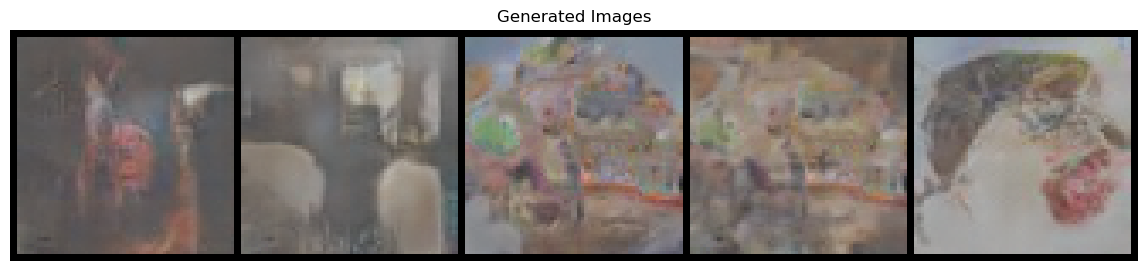

In [21]:
# Generate and visualize
G.eval()
with torch.no_grad():
    noise = torch.randn(5, nz, 1, 1, device=device)
    fake_imgs = G(noise).cpu()
    fake_imgs = (fake_imgs + 1) / 2  # to [0,1]

    grid = make_grid(fake_imgs, nrow=5)
    npimg = grid.numpy()
    plt.figure(figsize=(15,3))
    plt.axis("off")
    plt.title("Generated Images")
    plt.imshow(np.transpose(npimg, (1,2,0)))
    plt.show()

    # Save generated samples
    for i, img in enumerate(fake_imgs):
        save_image(img, f"generated_sample_{i+1}.png")


In [34]:
from torchvision.utils import save_image
import torch
import os

os.makedirs("generated_10k", exist_ok=True)

G.eval()
with torch.no_grad():
    for i in range(10000):  # or 1000 for quick eval
        z = torch.randn(1, nz, 1, 1, device=device)
        fake = G(z).detach().cpu()
        save_image(fake, f"generated_10k/fake_{i:05d}.png", normalize=True)


In [35]:
metrics = calculate_metrics(
    input1='generated_10k',      # now with 1000–10K samples
    input2='real_images_10k',
    isc=True,
    fid=True,
    cuda=torch.cuda.is_available(),
    verbose=True
)

print("\nEvaluation Metrics:")
print(f"Inception Score (IS): {metrics['inception_score_mean']:.4f}")
print(f"Frechet Inception Distance (FID): {metrics['frechet_inception_distance']:.4f}")

Creating feature extractor "inception-v3-compat" with features ['logits_unbiased', '2048']
Extracting features from input1
Looking for samples non-recursivelty in "generated_10k" with extensions png,jpg,jpeg
Found 10000 samples
Processing samples:   0%|          | 0/10000 [00:00<?, ?samples/s]/opt/anaconda3/lib/python3.12/site-packages/torch_fidelity/datasets.py:16: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  img = torch.ByteTensor(torch.ByteStorage.from_buffer(img.tobytes())).view(height, width, 3)
/opt/anaconda3/lib/python3.12/site-packages/torch_fidelity/datasets.py:16: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using stor


Evaluation Metrics:
Inception Score (IS): 5.1851
Frechet Inception Distance (FID): 85.5599


Frechet Inception Distance: 85.5599315394054


In [10]:
print(torch.cuda.is_available())
print(device)
import torch

print("MPS available:", torch.backends.mps.is_available())
print("MPS built:", torch.backends.mps.is_built())


False
cpu
MPS available: True
MPS built: True
